# Demo 1 — *Using* Earth embeddings for prediction

**ISPRS 2026 Tutorial · Towards Geospatial Embeddings**

Earth embeddings turn a place into a vector of numbers — a "learned measurement" you can drop into
ordinary machine-learning tools. In this demo we use **two very different** pre-made embeddings and
see that each suits a different job:

| | **SatCLIP** | **AlphaEarth (AEF)** |
|---|---|---|
| what it embeds | a **location** (lat/lon) | every **10 m pixel** |
| resolution | coarse / global | fine / local |
| inputs (modality) | optical satellite imagery | many sensors (optical, radar, …) |
| good for | broad geography (climate, biome) | detailed mapping (e.g. crops) |

We'll train **simple linear probes** on top of each, compare AEF against raw satellite imagery, and
test **geographic transfer** — train in one place, predict in a place the model never saw.

> 💡 Runs on a free **CPU** runtime in a few minutes. A GPU is optional.

In [1]:
# === Setup ===
import os, sys, time, warnings
from pathlib import Path
RUNNING_IN_COLAB = "google.colab" in sys.modules
if RUNNING_IN_COLAB:
    !pip install -q huggingface_hub scikit-learn matplotlib pandas einops

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
warnings.filterwarnings("ignore")

# Pre-packaged data lives in a public Hugging Face dataset repo (no login needed).
DATA_REPO = "kklmmr/isprs26-earth-embeddings"   # public HF dataset (no login needed)

def fetch(filename):
    """Local file if present (organizer testing), else download from the Hub."""
    for base in (Path("local/demo1"), Path("../local/demo1")):
        if (base / filename).exists():
            return str(base / filename)
    from huggingface_hub import hf_hub_download
    return hf_hub_download(DATA_REPO, f"demo1/{filename}", repo_type="dataset")

## Part A — Coarse & global: predicting **biomes** with SatCLIP

[SatCLIP](https://github.com/microsoft/satclip) is a *location encoder*: give it a longitude/latitude
and it returns a 256-number vector that summarises what that place is like. It learned this by matching
locations to Sentinel-2 imagery across the globe — so nearby/similar environments get similar vectors.

Our task: predict a location's **biome** (one of 14 broad ecosystem types — tundra, desert, tropical
forest, …) from its embedding alone. We use ~18,000 random land points labelled from the
[RESOLVE Ecoregions 2017](https://ecoregions.world/) map.

18000 points | 14 biomes | 8 realms


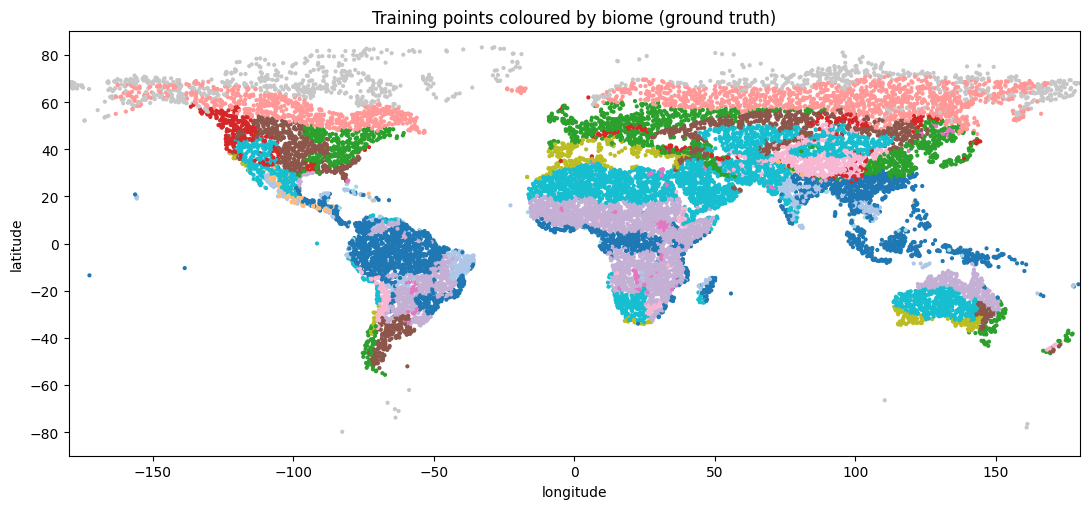

In [2]:
pts = pd.read_parquet(fetch("ecoregion_points.parquet"))
print(len(pts), "points |", pts["biome_num"].nunique(), "biomes |", pts["realm"].nunique(), "realms")

# Fixed colour per biome so every map below is consistent.
biome_codes = sorted(pts["biome_num"].unique())
biome_name  = dict(zip(pts["biome_num"], pts["biome_name"]))
BCMAP = plt.get_cmap("tab20", len(biome_codes))
bidx  = {c: i for i, c in enumerate(biome_codes)}

def biome_map(lon, lat, codes, title):
    plt.figure(figsize=(11, 5.2))
    plt.scatter(lon, lat, c=[bidx[c] for c in codes], cmap=BCMAP, s=4, vmin=0, vmax=len(biome_codes))
    plt.title(title); plt.xlabel("longitude"); plt.ylabel("latitude")
    plt.xlim(-180, 180); plt.ylim(-90, 90); plt.tight_layout(); plt.show()

biome_map(pts["lon"], pts["lat"], pts["biome_num"], "Training points coloured by biome (ground truth)")

### From coordinates to embeddings

We load SatCLIP and turn each (lon, lat) into a 256-d vector. (If the live install hiccups, we fall
back to embeddings we pre-computed with the exact same model.)

In [3]:
def satclip_embed(coords_lonlat):
    import torch
    from huggingface_hub import hf_hub_download
    if not os.path.exists("satclip"):
        os.system("git clone --depth 1 https://github.com/microsoft/satclip.git")
    sys.path.append("satclip/satclip")
    from load_lightweight import get_satclip_loc_encoder       # lightweight: only needs einops
    ckpt = hf_hub_download("microsoft/SatCLIP-ViT16-L40", "satclip-vit16-l40.ckpt")
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    enc = get_satclip_loc_encoder(ckpt, device=dev).to(dev)
    coords = torch.tensor(coords_lonlat, dtype=torch.float64, device=dev)
    with torch.no_grad():
        out = [enc(coords[s:s+8192]).cpu().numpy() for s in range(0, len(coords), 8192)]
    return np.concatenate(out).astype(np.float32)

t = time.time()
coords = pts[["lon", "lat"]].values
try:
    print("A few example embeddings (first 5 dims):")
    print(np.round(satclip_embed(coords[:2])[:, :5], 3))
    E = satclip_embed(coords)
except Exception as err:
    print("Live SatCLIP failed, using pre-computed fallback:", err)
    emb = pd.read_parquet(fetch("satclip_embeddings.parquet"))
    E = emb[[f"e{i}" for i in range(256)]].values.astype(np.float32)
print(f"SatCLIP embeddings: {E.shape}  [{time.time()-t:.1f}s]")

A few example embeddings (first 5 dims):


Cloning into 'satclip'...


[[ 0.904  4.237  0.143  0.431 -2.049]
 [-1.651  2.598  0.913 -0.084  6.64 ]]


SatCLIP embeddings: (18000, 256)  [6.5s]


### Train a linear probe → biome

A linear classifier on top of the embeddings is all we need.

SatCLIP -> biome  test accuracy = 86.4%


raw lon/lat -> biome  test accuracy = 42.3%   (embeddings add real signal!)


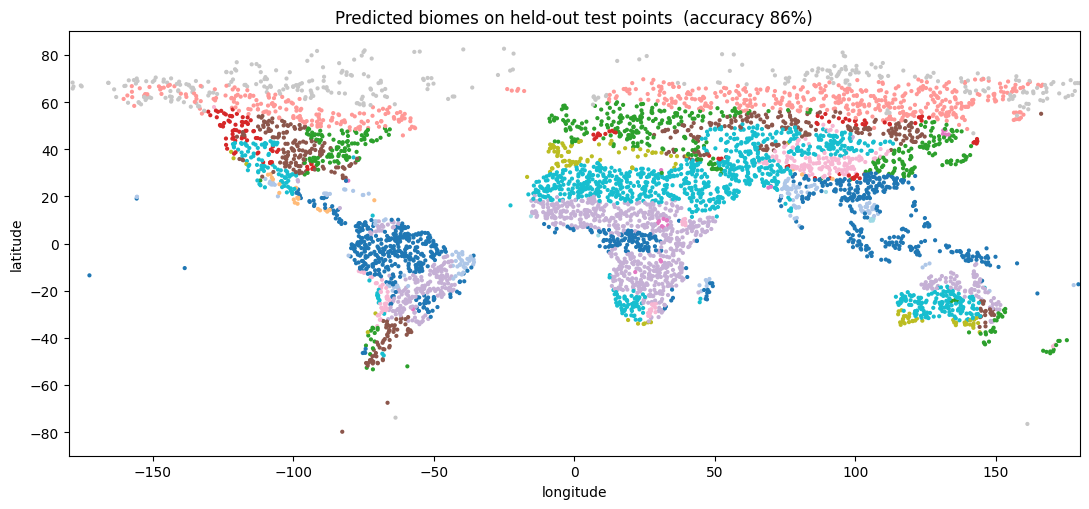

In [4]:
y = pts["biome_num"].values
Xtr, Xte, ytr, yte, itr, ite = train_test_split(E, y, np.arange(len(y)),
                                                test_size=0.3, random_state=0, stratify=y)
scaler = StandardScaler().fit(Xtr)
clf = LogisticRegression(max_iter=2000).fit(scaler.transform(Xtr), ytr)
acc = clf.score(scaler.transform(Xte), yte)
print(f"SatCLIP -> biome  test accuracy = {acc:.1%}")

# How good is that? Compare to a probe that only sees the raw coordinates.
Craw = pts[["lon", "lat"]].values
sc2 = StandardScaler().fit(Craw[itr])
base = LogisticRegression(max_iter=2000).fit(sc2.transform(Craw[itr]), ytr)
base_acc = base.score(sc2.transform(Craw[ite]), yte)
print(f"raw lon/lat -> biome  test accuracy = {base_acc:.1%}   (embeddings add real signal!)")

biome_map(pts["lon"].values[ite], pts["lat"].values[ite], clf.predict(scaler.transform(Xte)),
          f"Predicted biomes on held-out test points  (accuracy {acc:.0%})")

### Geographic transfer: predict in a region the model never saw

Real deployments often train where labels exist and predict elsewhere. We hold out an **entire
biogeographic realm** (e.g. the *Neotropic* — Central & South America), train on the rest of the
world, and test only on the held-out realm.

Train on world \ Neotropic; test on Neotropic (2642 pts): accuracy = 52.7%
(vs 86.4% when train/test are mixed) — accuracy drops on truly unseen geography.


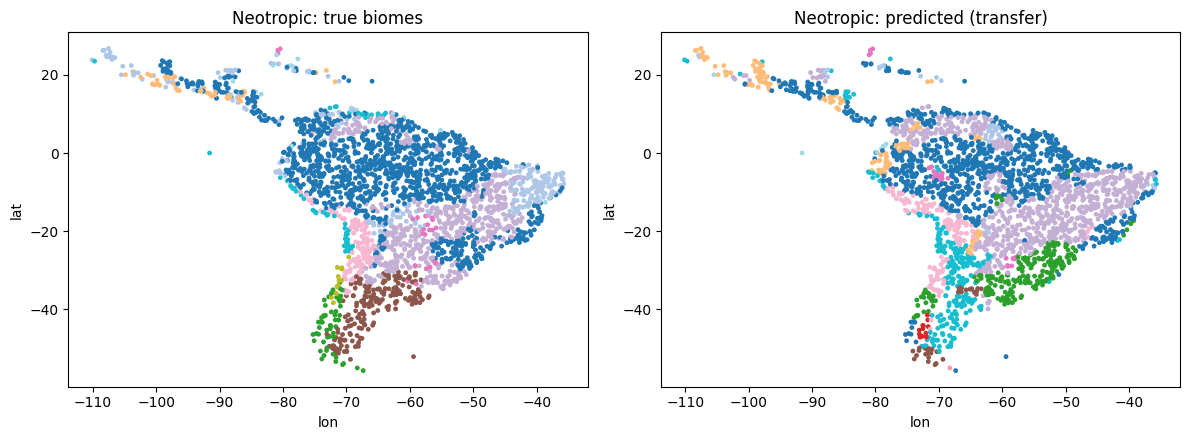

In [5]:
HOLDOUT = "Neotropic"
mask = pts["realm"].values == HOLDOUT
sc3 = StandardScaler().fit(E[~mask])
clf_t = LogisticRegression(max_iter=2000).fit(sc3.transform(E[~mask]), y[~mask])
acc_t = clf_t.score(sc3.transform(E[mask]), y[mask])
print(f"Train on world \\ {HOLDOUT}; test on {HOLDOUT} ({mask.sum()} pts): accuracy = {acc_t:.1%}")
print(f"(vs {acc:.1%} when train/test are mixed) — accuracy drops on truly unseen geography.")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for a, codes, ttl in [(ax[0], y[mask], f"{HOLDOUT}: true biomes"),
                      (ax[1], clf_t.predict(sc3.transform(E[mask])), f"{HOLDOUT}: predicted (transfer)")]:
    a.scatter(pts["lon"].values[mask], pts["lat"].values[mask],
              c=[bidx[c] for c in codes], cmap=BCMAP, s=6, vmin=0, vmax=len(biome_codes))
    a.set_title(ttl); a.set_xlabel("lon"); a.set_ylabel("lat")
plt.tight_layout(); plt.show()

## Part B — Fine-grained & local: **crop-type mapping** with AlphaEarth

[AlphaEarth Foundations](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_SATELLITE_EMBEDDING_V1_ANNUAL)
(AEF) is very different from SatCLIP: it gives a **64-number vector for every 10 m pixel**, distilled
from a whole year of *many* sensors (optical **and** radar, …). That richness is exactly what
fine-grained tasks like telling **canola from wheat from lentils** need.

We sampled AEF pixels over a Canadian Prairie region (Saskatchewan) and labelled them with the
[AAFC Annual Crop Inventory](https://developers.google.com/earth-engine/datasets/catalog/AAFC_ACI).

In [6]:
train = pd.read_parquet(fetch("aef_crop_train.parquet"))
AEF = [c for c in train.columns if c.startswith("A") and c[1:].isdigit()]   # A00..A63
S2  = [c for c in train.columns if c.startswith("B")]                       # Sentinel-2 bands
print(f"{len(train)} labelled pixels | {len(AEF)} AEF dims | {len(S2)} S2 bands")
print(train["crop_name"].value_counts().to_string())

# consistent colours for crop classes
crop_codes = sorted(train["crop_label"].unique())
crop_name  = {c: train.loc[train["crop_label"] == c, "crop_name"].iloc[0] for c in crop_codes}
CCMAP = plt.get_cmap("tab10", len(crop_codes))
cidx  = {c: i for i, c in enumerate(crop_codes)}

3000 labelled pixels | 64 AEF dims | 10 S2 bands
crop_name
Barley             500
Oats               500
Spring Wheat       500
Canola/Rapeseed    500
Peas               500
Lentils            500


AlphaEarth embeddings -> crop type:  test accuracy = 82.0%


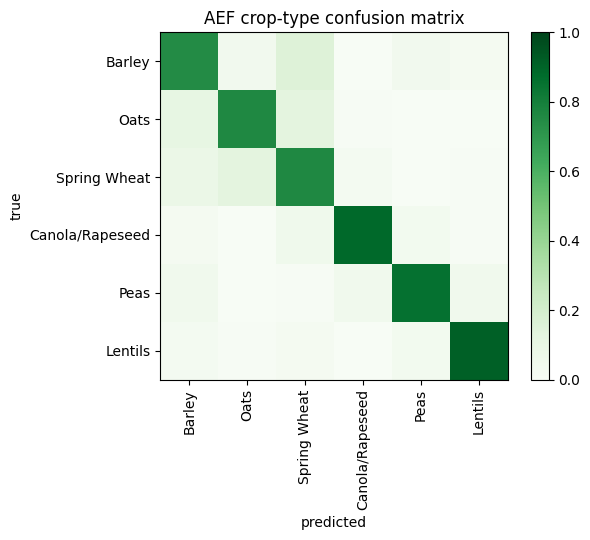

In [7]:
def crop_probe(feature_cols):
    Xtr, Xte, ytr, yte = train_test_split(train[feature_cols].values, train["crop_label"].values,
                                          test_size=0.3, random_state=0, stratify=train["crop_label"].values)
    sc = StandardScaler().fit(Xtr)
    clf = LogisticRegression(max_iter=2000).fit(sc.transform(Xtr), ytr)
    return clf, sc, clf.score(sc.transform(Xte), yte), (yte, clf.predict(sc.transform(Xte)))

clf_aef, sc_aef, acc_aef, (yte_c, pred_c) = crop_probe(AEF)
print(f"AlphaEarth embeddings -> crop type:  test accuracy = {acc_aef:.1%}")

cm = confusion_matrix(yte_c, pred_c, labels=crop_codes, normalize="true")
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Greens", vmin=0, vmax=1)
names = [crop_name[c] for c in crop_codes]
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=90)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); plt.colorbar(im, fraction=0.046)
plt.title("AEF crop-type confusion matrix"); plt.tight_layout(); plt.show()

### Embeddings vs. raw satellite imagery

Is the embedding actually better than the pixels it was built from? We train the **same** linear probe
on raw **Sentinel-2** reflectance (a growing-season median) at the same locations and compare.

AlphaEarth (64-d)      -> 82.0%
Sentinel-2 reflectance -> 49.4%


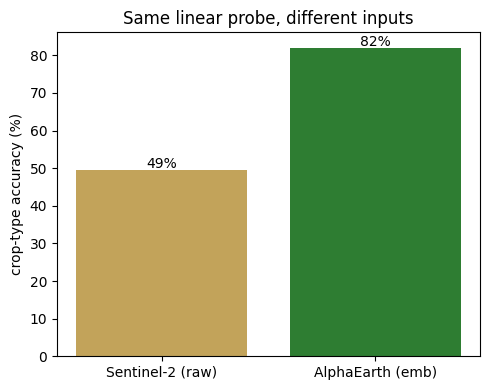

In [8]:
_, _, acc_s2, _ = crop_probe(S2)
print(f"AlphaEarth (64-d)      -> {acc_aef:.1%}")
print(f"Sentinel-2 reflectance -> {acc_s2:.1%}")

plt.figure(figsize=(5, 4))
plt.bar(["Sentinel-2 (raw)", "AlphaEarth (emb)"], [acc_s2*100, acc_aef*100],
        color=["#c2a35a", "#2e7d32"])
for i, v in enumerate([acc_s2, acc_aef]):
    plt.text(i, v*100 + 0.5, f"{v:.0%}", ha="center")
plt.ylabel("crop-type accuracy (%)"); plt.title("Same linear probe, different inputs")
plt.tight_layout(); plt.show()

### Make a crop map (and transfer it to an unseen region)

Finally we apply the AEF crop classifier across a dense grid of pixels to draw a **map**, and then —
without retraining — apply that *same* model to a **different Prairie region** (Manitoba) it never saw.

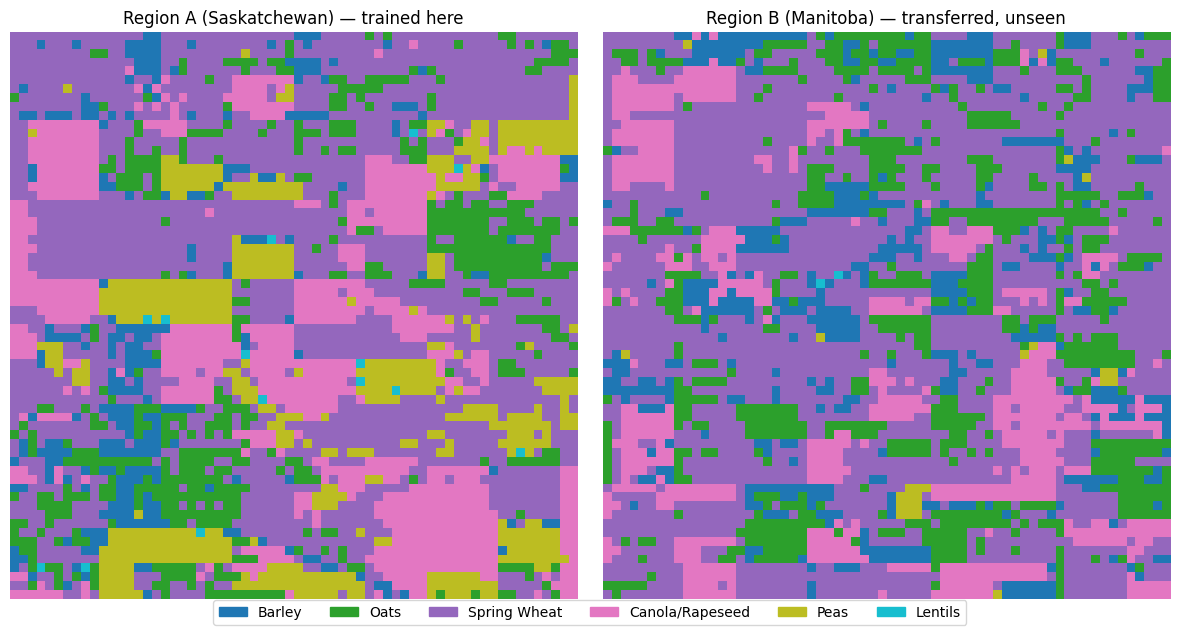

Crop-type accuracy transferred to region B: 54.3%  (vs 82.0% in region A)


In [9]:
def crop_map_panel(ax, grid_file, title):
    grid = pd.read_parquet(fetch(grid_file)).dropna(subset=AEF)
    side = int(grid["row"].max()) + 1
    pred = clf_aef.predict(sc_aef.transform(grid[AEF].values))
    img = np.full((side, side), np.nan)
    for r, c, p in zip(grid["row"].astype(int), grid["col"].astype(int), pred):
        img[r, c] = cidx[p]
    ax.imshow(img, cmap=CCMAP, vmin=0, vmax=len(crop_codes)); ax.set_title(title); ax.axis("off")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
crop_map_panel(ax[0], "aef_crop_grid.parquet",   "Region A (Saskatchewan) — trained here")
crop_map_panel(ax[1], "aef_crop_grid_B.parquet", "Region B (Manitoba) — transferred, unseen")
handles = [plt.Rectangle((0, 0), 1, 1, color=CCMAP(cidx[c])) for c in crop_codes]
fig.legend(handles, [crop_name[c] for c in crop_codes], loc="lower center",
           ncol=len(crop_codes), bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(); plt.show()

# Quantify the transfer on labelled points in region B.
test = pd.read_parquet(fetch("aef_crop_test.parquet"))
test = test[test["crop_label"].isin(crop_codes)]
acc_B = (clf_aef.predict(sc_aef.transform(test[AEF].values)) == test["crop_label"].values).mean()
print(f"Crop-type accuracy transferred to region B: {acc_B:.1%}  (vs {acc_aef:.1%} in region A)")

### Optional — reproduce the AlphaEarth data yourself (Google Earth Engine)

We pre-packaged the data so nobody needs an Earth Engine account during the tutorial. If you *do* have
one, this is all it takes to sample AEF + crop labels yourself (this cell is illustrative — see
`scripts/prep_demo1_aef_cropland.py` for the full version):

```python
import ee; ee.Authenticate(); ee.Initialize(project="YOUR_PROJECT")
region = ee.Geometry.Rectangle([-107.0, 51.5, -105.5, 52.5])           # Saskatchewan
aef = (ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
         .filterDate("2023-01-01", "2024-01-01").filterBounds(region).mosaic())   # 64-d, 10 m
aci = ee.ImageCollection("AAFC/ACI").filterDate("2023-01-01","2024-01-01").first().select(["landcover"])
sample = aef.addBands(aci).stratifiedSample(numPoints=800, classBand="landcover",
                                            region=region, scale=10, geometries=True)
df = ee.data.computeFeatures({"expression": sample, "fileFormat": "PANDAS_DATAFRAME"})
```

## Wrap-up

* **Match the embedding to the task.** SatCLIP's coarse *location* embeddings nailed **biomes**;
  AlphaEarth's fine *per-pixel* embeddings nailed **crop types** — and beat raw Sentinel-2 with the
  *same* linear probe.
* **Embeddings >> raw inputs** for simple models: they pack messy multi-sensor, multi-date signal into
  a tidy vector a linear classifier can use.
* **Geographic transfer works, but degrades.** Models carry useful structure to unseen places, yet
  accuracy drops the more "new" the target region is — worth measuring before you trust a map.

See these ideas at planetary scale in **LGND's *Discover*** app. Further resources: *SatCLIP*,
*AlphaEarth Foundations*, the tutorial's *Taxonomy of Embeddings*, and *TorchGeo*.